In [ ]:
! pip install -U nltk pandas numpy requests tabulate regex stanza tqdm torch transformers sentence-transformers scikit-learn imbalanced-learn plotly -q


In [ ]:
# Load data as DataFrame
import pandas as pd
import numpy as np
import logging
import warnings
import os
# Load the dataset
# df = pd.read_csv('/kaggle/input/final-data-for-modeling/final_dataset_for_modeling.csv', encoding='utf-8-sig') #################

# Display basic information about the data
print("Data shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())
print("\nFirst few rows:")
df.head()

Data shape: (36525, 5)

Columns:
['text', 'processed_text', 'lemmatized_text', 'category', 'encoded_category']

First few rows:
                                                text  \
0  كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...   
1  يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...   
2  شكلت تلك الجهود والمساعي الرائدة التي قام بها ...   
3  يقوم المقال على اشكالية الضرائب الغير شرعية في...   
4  تتفق المصادر التاريخية المتوفرة حول موضوع تطور...   

                                      processed_text  \
0  ربط صدر ارخ دلس خصه كتب رجم هرس رمج وغر درس حي...   
1  يعد عمل ثقف احد برز سبب يعز سقط دول وحد حتي ان...   
2  شكل جهد سعي رئد قده ثور خلل رحل اول بحث صدر مو...   
3  يقم قال علي شكل ضرب غير شرع خلف رحل دول ربط وح...   
4  تفق صدر ارخ توفر حول وضع تطر حرك وطن جزر نهي ح...   

                                     lemmatized_text           category  \
0  ارتبطت المصادر التاريخيه الاندلس خاصه كتب التر...  original_abstract   
1  يعد العامل الثقافي احد ابرز الاسباب يعزي سقوط

In [5]:
# Import libraries
import nltk
nltk.download('stopwords', quiet=True)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Visualization and data handling
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import regex as re
from tqdm import tqdm

# NLP and ML tools
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch
from tabulate import tabulate
import plotly.express as px

# Arabic stopwords
from nltk.corpus import stopwords
arabic_stopwords = set(stopwords.words('arabic'))
! pip install stanza
# Load Stanza Arabic pipeline
import stanza
stanza.download('ar', logging_level='ERROR')  # Suppress Stanza logs
nlp = stanza.Pipeline(lang='ar', processors='tokenize,pos,lemma,depparse', use_gpu=False)

# Arabic Unicode pattern
arabic_pattern = re.compile(r'[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF]')

# Sentence splitter pattern
sentence_splitter = re.compile(r'[\.\!\?؟؛:،\-–()"\[\]]+')

# Load AraBERT model
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv2")
model = AutoModel.from_pretrained("aubmindlab/bert-base-arabertv2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.0 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [14]:
# ############################### Feature 12: Number of short words / N #################################################
# # Short words ratio
import nltk
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize
from tqdm import tqdm

# Download punkt_tab if not already present
nltk.download('punkt_tab', quiet=True)

# Assuming arabic_stopwords is defined elsewhere
# Example: arabic_stopwords = set(stopwords.words('arabic')) if using NLTK stopwords

def word_counts(text, short_length=3):
    if pd.isna(text) or not isinstance(text, str) or len(text.strip()) == 0:
        return 0, 0, 0
    tokens = word_tokenize(text)
    total_words = len(tokens)
    tokens_no_stop = [word for word in tokens if word not in arabic_stopwords]
    short_count = sum(1 for word in tokens_no_stop if len(word) <= short_length)
    stopwords_count = len(tokens) - len(tokens_no_stop)
    return total_words, stopwords_count, short_count

# Your existing code
batch_size = 1000
short_results = []
for start in tqdm(range(0, len(df), batch_size), desc="Short Words"):
    end = min(start + batch_size, len(df))
    batch = df['text'].iloc[start:end]
    short_results.extend(batch.apply(word_counts))

df[['total_words', 'stopwords_count', 'short_words_count']] = pd.DataFrame(short_results, index=df.index)
max_words = df['total_words'].max()
df['short_words_ratio'] = df['short_words_count'] / df['total_words'].replace(0, np.nan).fillna(0)
df['total_words_ratio'] = df['total_words'] / max_words if max_words > 0 else 0

# Display summary
print("Short Words Feature Extracted")
print("\n" + "="*60)
print(df[['total_words', 'short_words_count', 'short_words_ratio']].describe().round(2))

# Group by category and calculate statistics
category_stats = df.groupby('category').agg({
    'total_words': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'short_words_count': ['mean', 'median', 'std'],
    'short_words_ratio': ['mean', 'median', 'std', 'min', 'max']
}).round(3)

category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns]
category_stats = category_stats.reset_index()

# Additional insights
print("\n" + "="*60)
print("AVERAGE SHORT WORDS RATIO")
print("="*60)
top_categories = df.groupby('category')['short_words_ratio'].mean().sort_values(ascending=False).round(3)
print(top_categories)

print("\n" + "="*60)
print("CATEGORY SHORT WORDS COMPARISON")
print("="*60)

# Create comparison table
comparison_table = pd.DataFrame({
    'Category': category_stats['category'],
    'Avg Total Words': category_stats['total_words_mean'].round(0),
    'Avg Short Words': category_stats['short_words_count_mean'].round(0),
    'Short Words Ratio (%)': (category_stats['short_words_ratio_mean'] * 100).round(1)
})

# Add Ratio Rank based on Short Words Ratio (%) in descending order
comparison_table['Ratio Rank'] = comparison_table['Short Words Ratio (%)'].rank(ascending=False, method='min').astype(int)
# Set Category as index
comparison_table = comparison_table.set_index('Category')
# Display the table
print(comparison_table)

Short Words: 100%|██████████| 37/37 [00:25<00:00,  1.43it/s]

Short Words Feature Extracted

       total_words  short_words_count  short_words_ratio
count     36524.00           36524.00           36524.00
mean        108.50              10.14               0.09
std          42.17               5.48               0.03
min          31.00               1.00               0.01
25%          80.00               7.00               0.07
50%         106.00               9.00               0.09
75%         129.00              12.00               0.11
max        2955.00             302.00               0.45

AVERAGE SHORT WORDS RATIO
category
jais_generated_abstract      0.108
original_abstract            0.098
allam_generated_abstract     0.097
llama_generated_abstract     0.089
openai_generated_abstract    0.081
Name: short_words_ratio, dtype: float64

CATEGORY SHORT WORDS COMPARISON
                           Avg Total Words  Avg Short Words  \
Category                                                      
allam_generated_abstract              98.0    

In [7]:
################################ Feature 33: Total number of lines (L) #################################
def extract_total_lines_and_sentences_improved(
    df: pd.DataFrame,
    text_column: str = 'processed_text',
    batch_size: int = 1000
) -> pd.DataFrame:
    print("\n" + "=" * 80)
    print("Task 3.3 — Feature 33: Total Number of Lines (L)")
    print("=" * 80)
    # Validate Input Column
    if text_column not in df.columns:
        raise ValueError(
            f"Column '{text_column}' not found in DataFrame. "
            f"Available columns: {list(df.columns)}"
        )
    # Step: Clean the DataFrame - Drop invalid rows
    initial_rows = len(df)
    df = df.dropna(subset=[text_column])
    df = df[df[text_column].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)]
    df = df.reset_index(drop=True)
    cleaned_rows = len(df)
    # Define Regex for Sentence Splitting
    sentence_splitter = re.compile(r'[\.!\?؟؛:،\-–()"\[\]]+')

    def extract_line_features(text: str) -> tuple:
        """Extract physical lines and sentence count from text."""
        if not text or not str(text).strip():
            return 1, 1

        # 1. Total Physical Lines
        physical_lines = [line.strip() for line in str(text).splitlines() if line.strip()]
        total_physical_lines = len(physical_lines)

        # 2. Total Sentences
        normalized_text = re.sub(r'\s+', ' ', str(text).strip())
        sentences = sentence_splitter.split(normalized_text)
        clean_sentences = [
            re.sub(r'[^\w\s]', '', s).strip()
            for s in sentences
            if len(s.strip()) > 3
        ]
        total_sentences = len([s for s in clean_sentences if s])

        return total_physical_lines, total_sentences
    # Batch Processing: Apply Features
    print(f"\nProcessing {cleaned_rows:,} rows in batches of {batch_size:,}...")
    line_features = []

    for start in tqdm(range(0, len(df), batch_size), desc="Extracting Line Features"):
        end = min(start + batch_size, len(df))
        batch = df[text_column].iloc[start:end]
        batch_results = batch.apply(extract_line_features)
        line_features.extend(batch_results.tolist())

    # Add features to DataFrame
    line_df = pd.DataFrame(line_features, columns=['total_physical_lines', 'total_sentence_count'])
    df[['total_physical_lines', 'total_sentence_count']] = line_df
    # OVERALL SUMMARY STATISTICS
    print("\n" + "-" * 80)
    print("OVERALL SUMMARY STATISTICS")
    print("-" * 80)
    agg_funcs = ['mean', 'std', 'min', 'max']
    summary_stats = df[['total_physical_lines', 'total_sentence_count']].agg(agg_funcs).round(2).T
    print(tabulate(summary_stats, headers=agg_funcs, tablefmt='psql'))
    # CATEGORY-BASED COMPARISON (MAIN ENHANCEMENT)
    if 'category' in df.columns:
        print("\n" + "=" * 80)
        print("CATEGORY COMPARISON: LINES vs SENTENCES RANKING")
        print("=" * 80)

        # 1. Calculate statistics by category
        category_stats = df.groupby('category')[['total_physical_lines', 'total_sentence_count']].agg({
            'total_physical_lines': ['mean', 'count'],
            'total_sentence_count': ['mean']
        }).round(2)

        # Flatten column names
        category_stats.columns = ['Avg_Lines', 'Total_Samples', 'Avg_Sentences']
        category_stats = category_stats.reset_index()

        # 2. Create ranking tables
        ranking_lines = category_stats[['category', 'Avg_Lines', 'Total_Samples']].sort_values('Avg_Lines', ascending=False)
        ranking_sentences = category_stats[['category', 'Avg_Sentences', 'Total_Samples']].sort_values('Avg_Sentences', ascending=False)

        # 3. Detailed comparison table
        comparison_table = pd.DataFrame({
            'Category': ranking_lines['category'],
            'Avg_Lines': ranking_lines['Avg_Lines'],
            'Lines_Rank': range(1, len(ranking_lines) + 1),
            'Avg_Sentences': ranking_sentences['Avg_Sentences'].reindex(ranking_lines.index).values,
            'Sentences_Rank': ranking_sentences['Avg_Sentences'].rank(ascending=False).reindex(ranking_lines.index).astype(int),
            'Line_to_Sentence_Ratio': (ranking_lines['Avg_Lines'] / ranking_sentences['Avg_Sentences'].reindex(ranking_lines.index)).round(2),
            'Total_Samples': ranking_lines['Total_Samples']
        })

        # 4. Print ranking tables
        print("\nTOP CATEGORIES BY AVERAGE PHYSICAL LINES:")
        print(tabulate(ranking_lines.head(10), headers='keys', tablefmt='psql', showindex=False))
        print("\nTOP CATEGORIES BY AVERAGE SENTENCES:")
        print(tabulate(ranking_sentences.head(10), headers='keys', tablefmt='psql', showindex=False))
        # 5. Print detailed comparison
        print("\nDETAILED COMPARISON TABLE:")
        print(tabulate(comparison_table, headers='keys', tablefmt='psql', showindex=False))
    # TOTAL SUMMARY
    print("\n" + "-" * 80)
    print("FINAL TOTALS")
    print("-" * 80)
    print(f"Total Physical Lines: {df['total_physical_lines'].sum():,} lines")
    print(f"Total Sentences: {df['total_sentence_count'].sum():,} sentences")
    print(f"Average Lines per Text: {df['total_physical_lines'].mean():.1f}")
    print(f"Average Sentences per Text: {df['total_sentence_count'].mean():.1f}")
    return df
# Execute the Function
df = extract_total_lines_and_sentences_improved(df, text_column='processed_text', batch_size=1000)



Task 3.3 — Feature 33: Total Number of Lines (L)

Processing 36,524 rows in batches of 1,000...


Extracting Line Features: 100%|██████████| 37/37 [00:12<00:00,  2.87it/s]



--------------------------------------------------------------------------------
OVERALL SUMMARY STATISTICS
--------------------------------------------------------------------------------
+----------------------+--------+-------+-------+-------+
|                      |   mean |   std |   min |   max |
|----------------------+--------+-------+-------+-------|
| total_physical_lines |   1    |  0    |     1 |     1 |
| total_sentence_count |   5.79 |  3.12 |     1 |   160 |
+----------------------+--------+-------+-------+-------+

CATEGORY COMPARISON: LINES vs SENTENCES RANKING

TOP CATEGORIES BY AVERAGE PHYSICAL LINES:
+---------------------------+-------------+-----------------+
| category                  |   Avg_Lines |   Total_Samples |
|---------------------------+-------------+-----------------|
| allam_generated_abstract  |           1 |            8388 |
| jais_generated_abstract   |           1 |            8382 |
| llama_generated_abstract  |           1 |            8374 

Foreign Letters Analysis: 100%|██████████| 37/37 [00:31<00:00,  1.17it/s]



Foreign Letters Feature Extracted
       foreign_letters_count  foreign_letters_ratio
count               36524.00               36524.00
mean                    0.58                   0.00
std                     2.76                   0.01
min                     0.00                   0.00
25%                     0.00                   0.00
50%                     0.00                   0.00
75%                     0.00                   0.00
max                    74.00                   0.17
======================================== Foreign Letters Feature by Categories ========================================
                    category  mean
0   llama_generated_abstract  0.98
1          original_abstract  0.83
2   allam_generated_abstract  0.49
3    jais_generated_abstract  0.49
4  openai_generated_abstract  0.29


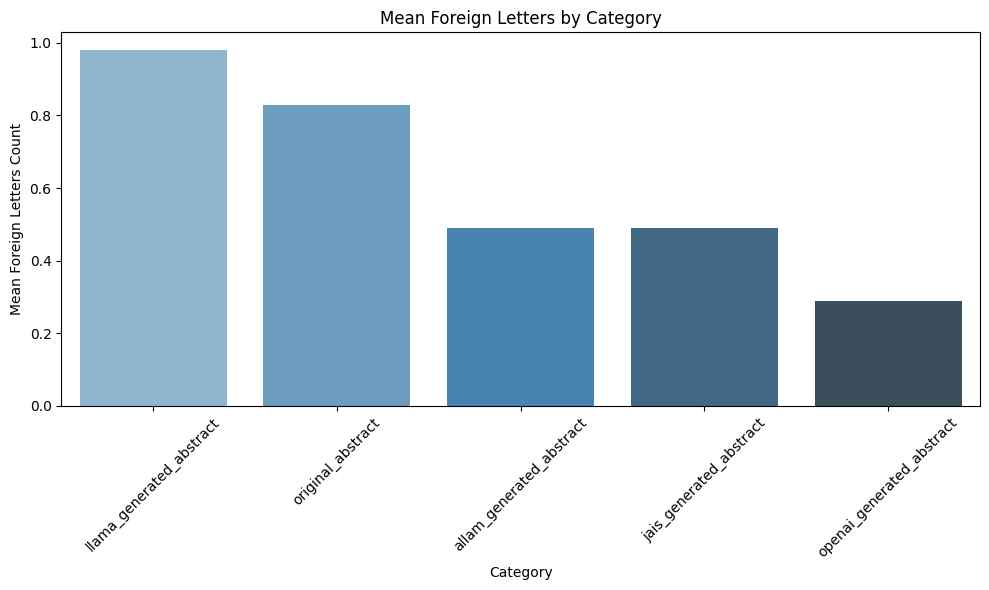

In [8]:
############################################### Feature 54: Number of foreign letters ##############################################
# Function to compute foreign letter count and ratio
def compute_foreign(text):
    if pd.isna(text) or not isinstance(text, str) or len(text.strip()) == 0:
        return 0, 0.0
    letters = [c for c in text if c.isalpha()]
    total_letters = len(letters)
    foreign_count = sum(1 for c in letters if not arabic_pattern.match(c))
    foreign_ratio = foreign_count / total_letters if total_letters > 0 else 0.0
    return foreign_count, foreign_ratio

# Apply the function in batches
foreign_results = []
for start in tqdm(range(0, len(df), batch_size), desc="Foreign Letters Analysis"):
    end = min(start + batch_size, len(df))
    batch = df['text'].iloc[start:end]
    foreign_results.extend(batch.apply(compute_foreign))

# Add results to the DataFrame
df[['foreign_letters_count', 'foreign_letters_ratio']] = pd.DataFrame(foreign_results, index=df.index)
print("\n" + "="*60)
# Display statistical summary
print("Foreign Letters Feature Extracted")
print(df[['foreign_letters_count', 'foreign_letters_ratio']].describe().round(2))

# Group by category and calculate mean
print("="*40, "Foreign Letters Feature by Categories", '='*40)
summary = df.groupby('category')['foreign_letters_count'].agg(['mean']).round(2)
summary = summary.sort_values(by='mean', ascending=False).reset_index()
print(summary)

# Visualization function using seaborn
def plot_foreign_letters(summary_df):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x='category', y='mean', palette='Blues_d')
    plt.xlabel('Category')
    plt.ylabel('Mean Foreign Letters Count')
    plt.title('Mean Foreign Letters by Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_foreign_letters(summary)

In [ ]:
# ################################################ Feature 75: Number of active voice sentences ##############################################
import stanza
import pandas as pd
from tqdm import tqdm
from multiprocessing import Pool
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD MODEL ONCE
print("Loading Arabic model...")
stanza.download('ar')
nlp = stanza.Pipeline('ar', processors='tokenize,pos,lemma,depparse',
                      tokenize_pretokenized=False, verbose=False)
print("Model loaded!")

# 2. OPTIMIZED FUNCTION
def count_active_voice_fast(text):
    """Fast version - nlp loaded globally"""
    if not isinstance(text, str) or not text.strip():
        return 0

    try:
        doc = nlp(text)
        if not doc.sentences:
            return 0

        active = 0
        for sent in doc.sentences:
            if len(sent.words) < 2:
                continue
            deprels = [w.deprel for w in sent.words if w.deprel]
            if any(d == 'nsubj' for d in deprels):
                active += 1
        return active
    except:
        return 0

# 3. PROCESS ONLY 200 ROWS IN PARALLEL
print("Processing subset of 200 rows with MULTI-PROCESSING...")
# Select a subset of 200 rows
subset_df = df.head(200)  # Or use df.sample(200) for random sampling
texts = subset_df['lemmatized_text'].astype(str).tolist()

with Pool(processes=4) as pool:  # 4 cores = 4x faster
    active_results = list(tqdm(pool.imap(count_active_voice_fast, texts),
                              total=len(texts), desc="Active Voice"))

# 4. SAVE RESULTS
subset_df['Active_Voice_Count'] = active_results

# Optional: Save the subset with results to a new file if needed
subset_df.to_csv('subset_with_active_voice.csv', index=False)
print("Processing complete! Results saved to subset_with_active_voice.csv")

Loading Arabic model...
Model loaded!
Processing subset of 200 rows with MULTI-PROCESSING...


Active Voice: 100%|██████████| 200/200 [14:57<00:00,  4.49s/it]


Processing complete! Results saved to subset_with_active_voice.csv


In [10]:
#################################### Feature 97: Redundancy Score ##########################################
# Redundancy TF-IDF
def get_vectorizer(max_features=500):
    return TfidfVectorizer(analyzer='word', token_pattern=r'[^\W\d_]+', lowercase=True, max_features=max_features, norm='l2')

def redundancy_score(tfidf_vector, threshold=0.3):
    tfidf_array = tfidf_vector.toarray()[0]
    total_terms = np.count_nonzero(tfidf_array)
    return 0.0 if total_terms == 0 else min(1.0, sum(1 for val in tfidf_array if val < threshold) / total_terms)

def get_sentence_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

vectorizer = get_vectorizer()
data = []
for idx, row in df.iterrows():
    units = re.findall(r'[^\W\d_]+', row['text'].strip())
    for unit in units:
        data.append({'original_index': idx, 'unit': unit})
unit_df = pd.DataFrame(data).dropna(subset=['unit'])
tfidf_matrix = vectorizer.fit_transform(unit_df['unit'])
scores = [redundancy_score(tfidf_matrix[i]) for i in range(tfidf_matrix.shape[0])]
unit_df['Redundancy_Score'] = scores
df['Redundancy_Score'] = unit_df.groupby('original_index')['Redundancy_Score'].mean()

print("\n==================== Redundancy Score Feature Extracted ====================")
print(df['Redundancy_Score'].describe().round(2))

grouped_stats = df.groupby('category')['Redundancy_Score'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
print("\n================ Statistic of Redundancy Score by Category =================")
print(grouped_stats)


==================== Redundancy Score Feature Extracted ====================
count    36524.00
mean         0.53
std          0.10
min          0.00
25%          0.46
50%          0.53
75%          0.60
max          0.91
Name: Redundancy_Score, dtype: float64

================ Statistic of Redundancy Score by Category =================
                           mean   std   min   max  count
category                                                
allam_generated_abstract   0.56  0.10  0.21  0.91   8388
jais_generated_abstract    0.54  0.10  0.12  0.90   8382
llama_generated_abstract   0.55  0.10  0.08  0.89   8374
openai_generated_abstract  0.52  0.07  0.20  0.77   8388
original_abstract          0.39  0.08  0.00  0.90   2992


# 1

In [ ]:
# =============================================
# 1: Install and Import Libraries (Run Once)
# =============================================
# Install required packages if not already available (uncomment if needed in Colab)
# !pip install nltk pandas numpy requests tabulate  # Added tabulate for consistency with previous scripts

# Import core libraries
import pandas as pd                  # Data manipulation and DataFrame handling
import nltk                          # Natural Language Toolkit for tokenization and stopwords
from nltk.tokenize import word_tokenize  # Word tokenization function
from nltk.corpus import stopwords    # Stopwords corpus
import numpy as np                   # Numerical operations (e.g., handling NaN)
import requests                      # HTTP requests to fetch external stopword list

# Check if NLTK data resources are already downloaded; download only if missing
def ensure_nltk_resources():
    """Check and download required NLTK resources only if not already available."""
    resources = {
        'punkt': 'tokenizers/punkt',
        'punkt_tab': 'tokenizers/punkt_tab',
        'stopwords': 'corpora/stopwords'
    }
    missing = []
    for name, path in resources.items():
        try:
            nltk.data.find(path)
        except LookupError:
            missing.append(name)

    if missing:
        print(f"Missing NLTK resources: {missing}. Downloading now...")
        for resource in missing:
            nltk.download(resource, quiet=True)
        print("NLTK resources downloaded successfully.")
    else:
        print("All required NLTK resources are already available.")

# Call the function to ensure resources
ensure_nltk_resources()

# Load the standard Arabic stopwords list from NLTK (~200 words)
arabic_stopwords = set(stopwords.words('arabic'))

# Extend with a larger, research-based standard Arabic stopword list (750+ words)
url = 'https://raw.githubusercontent.com/mohataher/arabic-stop-words/master/list.txt'
response = requests.get(url)
if response.status_code == 200:
    extended_stopwords = set(response.text.splitlines())
    arabic_stopwords.update(extended_stopwords)
    print(f"Extended Arabic stopword list loaded successfully: {len(arabic_stopwords)} words.")
else:
    print("Warning: Failed to load the extended stopword list. Using only NLTK default list.")


# =============================================
# 2: Function for Extracting Short Words Ratio
# =============================================
def extract_short_words_ratio(
    df: pd.DataFrame,
    text_column: str = 'processed_text',
    short_length: int = 3,
    remove_stopwords: bool = True
) -> pd.DataFrame:
    """
    Extracts the ratio of short words (length <= short_length) to the total number of words in the text.

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame containing text data.
    text_column : str, optional
        The name of the text column to process (default: 'processed_text').
    short_length : int, optional
        Maximum length to consider a word as 'short' (default: 3).
    remove_stopwords : bool, optional
        Whether to remove standard Arabic stopwords (default: True).

    Returns:
    --------
    pd.DataFrame
        The input DataFrame with a new column for the extracted feature.

    Notes:
    ------
    - Handles invalid entries (NaN, non-string, empty) by returning 0.0.
    - Uses NLTK word_tokenize (Arabic supported) and filters alphabetic tokens.
    - Extends stopwords with a standard external list for better coverage in Arabic NLP.
    """
    # --------------------------------------------------
    # Validate Input Column
    # --------------------------------------------------
    if text_column not in df.columns:
        raise ValueError(
            f"Column '{text_column}' not found in DataFrame! "
            f"Available columns: {list(df.columns)}"
        )

    # --------------------------------------------------
    # Helper Function: Compute Short Words Ratio for a Single Text
    # --------------------------------------------------
    def short_words_ratio(text: str) -> float:
        """Compute the ratio of short words after optional stopword removal."""
        # Step 1: Handle invalid or empty entries
        if pd.isna(text) or not isinstance(text, str) or len(text.strip()) == 0:
            return 0.0

        try:
            # Step 2: Tokenization (Arabic supported)
            tokens = word_tokenize(text)

            # Step 3: Filter out non-alphabetic tokens
            tokens = [word for word in tokens if word.isalpha()]

            # Step 3.5: Remove Arabic stopwords if enabled
            if remove_stopwords:
                tokens = [word for word in tokens if word not in arabic_stopwords]

            # Step 4: Calculate total words (N) and short words count
            N = len(tokens)
            if N == 0:
                return 0.0

            short_count = sum(1 for word in tokens if len(word) <= short_length)

            # Step 5: Compute the ratio
            return short_count / N

        except Exception as e:
            print(f"Warning: Unexpected error while processing text: {e}")
            return 0.0

    # --------------------------------------------------
    # Apply the Function and Add New Column
    # --------------------------------------------------
    new_column = f'short_words_ratio_{short_length}_rmstop_{remove_stopwords}'
    df[new_column] = df[text_column].apply(short_words_ratio)

    # --------------------------------------------------
    # Print Feature Extraction Summary
    # --------------------------------------------------
    print("\n" + "=" * 80)
    print(f"Feature Extraction Completed: Short Words Ratio (length <= {short_length})")
    print("=" * 80)
    print(f"New column added: '{new_column}'")

    # --------------------------------------------------
    # Category-Based Statistics (if applicable)
    # --------------------------------------------------
    if 'category' in df.columns:
        print("\nCategory-based Statistics (Mean/Std):")
        stats = df.groupby('category')[new_column].agg(['mean', 'std']).round(3)
        print(stats)

    # --------------------------------------------------
    # Print Task Footer
    # --------------------------------------------------
    print("\n" + "=" * 80)
    print("Short Words Ratio Feature computation completed successfully.")
    print("=" * 80)

    return df


# =============================================
# 3: Apply the Function
# =============================================
# Apply to your DataFrame (assuming 'df' is loaded with 'processed_text' column)
df = extract_short_words_ratio(
    df,
    text_column='processed_text',
    short_length=3,
    remove_stopwords=True
)

# =============================================
# Display 10 Random Rows for Verification
# =============================================
# Sample 10 random rows from the DataFrame (with fixed seed for reproducibility)
random_sample = df[['category', f'short_words_ratio_3_rmstop_True']].sample(n=10, random_state=42)
print(random_sample)

In [ ]:
# =============================================
# Import Required Libraries
# =============================================
import re                    # Regular expressions for pattern matching and splitting
import pandas as pd          # Data manipulation and DataFrame handling
from tabulate import tabulate  # Pretty-printing tables in console output


# =============================================
# Function Definition: Extract Total Lines and Sentences
# =============================================
def extract_total_lines_and_sentences_fixed(
    df: pd.DataFrame,
    text_column: str = 'processed_text'
) -> pd.DataFrame:
    """
    Compute Feature 33: Total Number of Lines (L) with Enhancements and Cleaning.

    This function calculates:
    1. Physical lines based on newline characters ('\n').
    2. Sentence-like lines based on punctuation (optimized for Arabic/English texts).

    New columns added:
    - 'total_physical_lines_text': Physical line count.
    - 'total_sentence_lines_text': Sentence segment count (fixed for accuracy).

    Additional steps:
    - Cleans the text column: Drops rows with NaN/empty/invalid text in the specified column.
    - Computes statistics only on cleaned data to avoid min=0 artifacts from nulls.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing the text data.
    text_column : str, optional
        Column name with preprocessed text (default: 'processed_text').

    Returns:
    --------
    pd.DataFrame
        Cleaned DataFrame with added feature columns.

    Notes:
    ------
    - Sentence counting is improved for Arabic academic texts using expanded regex,
      whitespace normalization, punctuation stripping, and length-based filtering.
    - Handles edge cases: NaN, non-string, empty texts by dropping invalid rows upfront.
    """
    # --------------------------------------------------
    # Print Task Header
    # --------------------------------------------------
    print("\n" + "=" * 80)
    print("Task 3.3 — Feature 33: Total Number of Lines (L) - Fixed Version with Cleaning")
    print("=" * 80)

    # --------------------------------------------------
    # Validate Input Column
    # --------------------------------------------------
    if text_column not in df.columns:
        raise ValueError(
            f"Column '{text_column}' not found in DataFrame. "
            f"Available columns: {list(df.columns)}"
        )

    # --------------------------------------------------
    # Step: Clean the DataFrame - Drop invalid rows in text_column
    # --------------------------------------------------
    initial_rows = len(df)
    df = df.dropna(subset=[text_column])  # Drop NaN in text column
    df = df[df[text_column].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)]  # Keep only valid non-empty strings
    df = df.reset_index(drop=True)  # Reset index after dropping
    cleaned_rows = len(df)
    print(f"Cleaning applied: Dropped {initial_rows - cleaned_rows} invalid rows (NaN/empty/non-string). Remaining rows: {cleaned_rows}")

    # --------------------------------------------------
    # Define Regex for Sentence Splitting
    # --------------------------------------------------
    # Expanded pattern covers Arabic/English punctuation common in academic texts
    sentence_splitter = re.compile(r'[\.!\?؟؛:،\-–()"\[\]]+')

    # --------------------------------------------------
    # Helper Function: Count Physical Lines
    # --------------------------------------------------
    def count_physical_lines(text: str) -> int:
        """Count physical lines using newline splits, ignoring empty lines."""
        try:
            lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
            return len(lines) if lines else 1
        except Exception as e:
            print(f"Warning in physical lines count: {e}")
            return 1  # Default to 1 for valid text

    # --------------------------------------------------
    # Helper Function: Count Sentence-Like Lines (Fixed)
    # --------------------------------------------------
    def count_sentence_lines(text: str) -> int:
        """Count sentences using punctuation splits with Arabic optimizations."""
        try:
            # Normalize whitespace (multiple spaces/newlines to single space)
            normalized_text = re.sub(r'\s+', ' ', text.strip())

            # Split on punctuation pattern
            sentences = sentence_splitter.split(normalized_text)

            # Post-processing: Remove residual punctuation, strip, filter short noise
            sentences = [
                re.sub(r'[^\w\s]', '', s).strip()
                for s in sentences
                if len(s.strip()) > 3  # Ignore very short segments (e.g., punctuation remnants)
            ]

            return len(sentences) if sentences else 1
        except Exception as e:
            print(f"Warning in sentence lines count: {e}")
            return 1  # Default to 1 for valid text

    # --------------------------------------------------
    # Apply Functions to DataFrame (on cleaned data)
    # --------------------------------------------------
    df['total_physical_lines_text'] = df[text_column].apply(count_physical_lines)
    df['total_sentence_lines_text'] = df[text_column].apply(count_sentence_lines)

    # --------------------------------------------------
    # Print Added Features Summary
    # --------------------------------------------------
    print("\nFeature columns added successfully:")
    print("- total_physical_lines_text")
    print("- total_sentence_lines_text")

    # --------------------------------------------------
    # Overall Summary Statistics (Enhanced with mean/std/min/max on cleaned data)
    # --------------------------------------------------
    print("\n" + "-" * 80)
    print("Summary Statistics - Mean/ Std/ Min/ Max")
    print("-" * 80)
    agg_funcs = ['mean', 'std', 'min', 'max']
    summary_stats = df[['total_physical_lines_text', 'total_sentence_lines_text']].agg(agg_funcs).round(3).T
    print(tabulate(summary_stats, headers=agg_funcs, tablefmt='psql'))

    # --------------------------------------------------
    # Category-Based Statistics (Enhanced with mean/std/min/max on cleaned data)
    # --------------------------------------------------
    if 'category' in df.columns:
        print("\n" + "-" * 80)
        print("Category-based Statistics - Mean/ Std/ Min/ Max")
        print("-" * 80)
        cat_stats = (
            df.groupby('category')[['total_physical_lines_text', 'total_sentence_lines_text']]
            .agg(['mean', 'std', 'min', 'max'])
            .round(3)
        )
        print(tabulate(cat_stats, headers='keys', tablefmt='psql', showindex=True))

    # --------------------------------------------------
    # Print Task Footer
    # --------------------------------------------------
    print("\n" + "=" * 80)
    print("Feature 33 computation completed successfully (with cleaning and enhanced stats).")
    print("=" * 80)

    return df


# =============================================
# Execute the Function
# =============================================
# Assuming 'df' is already loaded with the required data and 'processed_text' column
df = extract_total_lines_and_sentences_fixed(df, text_column='processed_text')

# =============================================
# Display 10 Random Rows for Verification (from cleaned data)
# =============================================
# Sample 10 random rows from the DataFrame (with fixed seed for reproducibility)
random_sample = df[['category', 'total_physical_lines_text', 'total_sentence_lines_text']].sample(n=10, random_state=42)
print(random_sample)

# 54

In [ ]:
# =============================================
# 1: Install and Import Libraries (Run Once)
# =============================================
# Install required packages if not already available (uncomment if needed in Colab)
# !pip install pandas numpy regex  # regex for Unicode pattern matching

# Import core libraries
import pandas as pd                  # Data manipulation and DataFrame handling
import numpy as np                   # Numerical operations
import regex as re                   # Advanced regex with Unicode support


# =============================================
# 2: Function for Extracting Number of Foreign Letters
# =============================================
def extract_foreign_letters_count(
    df: pd.DataFrame,
    text_column: str = 'original_text'  # Use original/raw text column
) -> pd.DataFrame:
    """
    Feature 54: Number of Foreign Letters (non-Arabic letters count).
    - Counts any alphabetic char not in Arabic Unicode ranges.
    - Works on original text to capture real foreign letters (e.g., French/Latin in Arabic data).
    """
    # --------------------------------------------------
    # Validate Input Column
    # --------------------------------------------------
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found! Available: {list(df.columns)}")

    # --------------------------------------------------
    # Regex for Arabic Script Ranges (exclude these from foreign count)
    # - \u0600-\u06FF: Arabic block (basic letters, harakat)
    # - \u0750-\u077F: Arabic Supplement (extended letters)
    # - \u08A0-\u08FF: Arabic Extended-A (Quran marks, rare forms)
    # - \uFB50-\uFDFF: Arabic Presentation Forms-A (ligatures)
    # - \uFE70-\uFEFF: Arabic Presentation Forms-B (more forms, zero-width)
    # --------------------------------------------------
    arabic_pattern = re.compile(r'[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF]')

    # --------------------------------------------------
    # Count Non-Arabic Letters
    # --------------------------------------------------
    def count_foreign(text: str) -> int:
        if pd.isna(text) or not isinstance(text, str) or len(text.strip()) == 0:
            return 0
        letters = [c for c in text if c.isalpha()]
        if not letters:
            return 0
        foreign_count = sum(1 for c in letters if not arabic_pattern.match(c))
        return foreign_count

    # --------------------------------------------------
    # Apply and Add Column
    # --------------------------------------------------
    new_column = 'foreign_letters_count'
    df[new_column] = df[text_column].apply(count_foreign)

    # --------------------------------------------------
    # Summary Stats
    # --------------------------------------------------
    print("\n" + "=" * 80)
    print("Feature 54: Foreign Letters Count")
    print("=" * 80)
    print(f"New column: '{new_column}' (on '{text_column}')")

    if 'category' in df.columns:
        stats = df.groupby('category')[new_column].agg(['mean', 'std', 'min', 'max']).round(3)
        print("Category Stats:")
        print(stats)

    print("\n" + "=" * 80)
    print("Display 10 Random Rows")
    print("=" * 80)

    return df


# =============================================
# 3: Apply the Function
# =============================================
df = extract_foreign_letters_count(df, text_column='text')  # Change to your original column

# =============================================
# Display 10 Random Rows
# =============================================
random_sample = df[['category', 'foreign_letters_count']].sample(n=10, random_state=42)
print(random_sample)

# **# 75 #################################################**

In [ ]:
######################### Full Sentences in TF-IDF ################################ Redundancy Score Analysis for Arabic Text

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re

# Initialize TfidfVectorizer for full sentences
vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[^\W\d_]+',
    lowercase=True,
    max_features=500,
    norm='l2'
)

# Load and clean data (replace with your actual data loading method)
# df = pd.read_csv('your_data.csv')

# Handle missing values in processed_text
df.dropna(subset=['processed_text'], inplace=True)

# Function to split text into sentences with enhanced Arabic punctuation support
def split_into_sentences(text):
    """
    Split Arabic text into sentences using a wide range of punctuation marks.
    Args:
        text: Input text to split
    Returns:
        List of sentences
    """
    pattern = r'[.!?؛،:۔()\[\]"'']+'
    sentences = re.split(pattern, text.strip())
    return [s.strip() for s in sentences if s.strip() and len(s.strip()) > 3]

# Extract sentences from processed_text and create a new DataFrame
sentence_data = []
for idx, row in df.iterrows():
    sentences = split_into_sentences(row['processed_text'])
    for sentence in sentences:
        sentence_data.append({
            'original_index': idx,
            'sentence': sentence,
            'category': row['category'],
            'encoded_category': row['encoded_category']
        })
sentence_df = pd.DataFrame(sentence_data)

# Handle missing values in sentences
sentence_df.dropna(subset=['sentence'], inplace=True)

# Transform sentences to TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(sentence_df['sentence'])

# Function to calculate Redundancy Score based on sentence repetition
def redundancy_score_sentences(text, tfidf_vector, threshold=0.1):
    """
    Calculate redundancy score based on sentence repetition using TF-IDF weights.
    Args:
        text: Original text to extract phrases
        tfidf_vector: TF-IDF vector for the text
        threshold: Threshold for low TF-IDF to indicate redundancy (default 0.1)
    Returns:
        Ratio of redundant terms/phrases to total terms (capped at 1.0)
    """
    tfidf_array = tfidf_vector.toarray()[0]
    feature_names = vectorizer.get_feature_names_out()
    total_terms = np.count_nonzero(tfidf_array)
    if total_terms == 0:
        return 0.0

    low_tfidf_terms = sum(1 for val, name in zip(tfidf_array, feature_names) if val < threshold)
    score = min(1.0, low_tfidf_terms / total_terms)
    return score

# Calculate Redundancy Score for each sentence
redundancy_scores = []
for i in range(len(sentence_df)):
    try:
        score = redundancy_score_sentences(sentence_df['sentence'].iloc[i], tfidf_matrix[i])
        redundancy_scores.append(score)
    except Exception as e:
        print(f"Error in sentence {i}: {e}")
        redundancy_scores.append(0.0)

# Add Redundancy Score to sentence DataFrame
sentence_df['Redundancy_Score'] = redundancy_scores

# Classify redundancy score for meaningful output
def classify_redundancy(score):
    if score >= 0.7:
        return "Very High Redundancy"
    elif score >= 0.4:
        return "Moderate Redundancy"
    else:
        return "Low Redundancy"

sentence_df['Redundancy_Classification'] = sentence_df['Redundancy_Score'].apply(classify_redundancy)

# Aggregate Redundancy Score back to original rows (e.g., average per document)
df['Redundancy_Score'] = sentence_df.groupby('original_index')['Redundancy_Score'].mean()
df['Redundancy_Classification'] = sentence_df.groupby('original_index')['Redundancy_Classification'].agg(
    lambda x: x.value_counts().idxmax()  # Select the most frequent classification
)

# # Display results with selected columns
# print("\n### Redundancy Analysis Results ###")
# print(df[['processed_text', 'Redundancy_Score', 'Redundancy_Classification', 'category', 'encoded_category']])

# Calculate and display statistics
stats = df['Redundancy_Score'].describe()
print("\n### Statistical Summary of Redundancy Scores ###")
print(stats)
print(f"\nNumber of texts with Very High Redundancy: {(df['Redundancy_Classification'] == 'Very High Redundancy').sum()}")
print(f"Number of texts with Moderate Redundancy: {(df['Redundancy_Classification'] == 'Moderate Redundancy').sum()}")
print(f"Number of texts with Low Redundancy: {(df['Redundancy_Classification'] == 'Low Redundancy').sum()}")

In [ ]:
# Redundancy Score Analysis for Arabic Text

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re

# Initialize TfidfVectorizer for full sentences
vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[^\W\d_]+',
    lowercase=True,
    max_features=500,
    norm='l2'
)

# Load and clean data (replace with your actual data loading method)
# df = pd.read_csv('your_data.csv')

# Handle missing values in processed_text
df.dropna(subset=['processed_text'], inplace=True)

# Function to split text into sentences with enhanced Arabic punctuation support
def split_into_sentences(text):
    """
    Split Arabic text into sentences using a wide range of punctuation marks.
    Args:
        text: Input text to split
    Returns:
        List of sentences
    """
    pattern = r'[.!?؛،:۔()\[\]"'']+'
    sentences = re.split(pattern, text.strip())
    return [s.strip() for s in sentences if s.strip() and len(s.strip()) > 3]

# Extract sentences from processed_text and create a new DataFrame
sentence_data = []
for idx, row in df.iterrows():
    sentences = split_into_sentences(row['processed_text'])
    for sentence in sentences:
        sentence_data.append({
            'original_index': idx,
            'sentence': sentence,
            'category': row['category'],
            'encoded_category': row['encoded_category']
        })
sentence_df = pd.DataFrame(sentence_data)

# Handle missing values in sentences
sentence_df.dropna(subset=['sentence'], inplace=True)

# Transform sentences to TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(sentence_df['sentence'])

# Function to calculate Redundancy Score based on sentence repetition
def redundancy_score_sentences(text, tfidf_vector, threshold=0.3):  # Increased threshold to 0.3
    """
    Calculate redundancy score based on sentence repetition using TF-IDF weights.
    Args:
        text: Original text to extract phrases
        tfidf_vector: TF-IDF vector for the text
        threshold: Threshold for low TF-IDF to indicate redundancy (default 0.3)
    Returns:
        Ratio of redundant terms/phrases to total terms (capped at 1.0)
    """
    tfidf_array = tfidf_vector.toarray()[0]
    feature_names = vectorizer.get_feature_names_out()
    total_terms = np.count_nonzero(tfidf_array)
    if total_terms == 0:
        return 0.0

    low_tfidf_terms = sum(1 for val, name in zip(tfidf_array, feature_names) if val < threshold)
    score = min(1.0, low_tfidf_terms / total_terms)
    return score

# Calculate Redundancy Score for each sentence
redundancy_scores = []
for i in range(len(sentence_df)):
    try:
        score = redundancy_score_sentences(sentence_df['sentence'].iloc[i], tfidf_matrix[i])
        redundancy_scores.append(score)
    except Exception as e:
        print(f"Error in sentence {i}: {e}")
        redundancy_scores.append(0.0)

# Add Redundancy Score to sentence DataFrame
sentence_df['Redundancy_Score'] = redundancy_scores

# Classify redundancy score for meaningful output
def classify_redundancy(score):
    if score >= 0.7:
        return "Very High Redundancy"
    elif score >= 0.4:
        return "Moderate Redundancy"
    else:
        return "Low Redundancy"

sentence_df['Redundancy_Classification'] = sentence_df['Redundancy_Score'].apply(classify_redundancy)

# Aggregate Redundancy Score back to original rows (e.g., average per document)
df['Redundancy_Score'] = sentence_df.groupby('original_index')['Redundancy_Score'].mean()
df['Redundancy_Classification'] = sentence_df.groupby('original_index')['Redundancy_Classification'].agg(
    lambda x: x.value_counts().idxmax()  # Select the most frequent classification
)

# Display results with selected columns
# print("\n### Redundancy Analysis Results ###")
# print(df[['processed_text', 'Redundancy_Score', 'Redundancy_Classification', 'category', 'encoded_category']])

# Calculate and display statistics
stats = df['Redundancy_Score'].describe()
print("\n### Statistical Summary of Redundancy Scores ###")
print(stats)
print(f"\nNumber of texts with Very High Redundancy: {(df['Redundancy_Classification'] == 'Very High Redundancy').sum()}")
print(f"Number of texts with Moderate Redundancy: {(df['Redundancy_Classification'] == 'Moderate Redundancy').sum()}")
print(f"Number of texts with Low Redundancy: {(df['Redundancy_Classification'] == 'Low Redundancy').sum()}")

# Display a portion of the TF-IDF matrix (first 5 sentences)
# print("\n### Sample TF-IDF Matrix (First 5 Sentences) ###")
sample_tfidf = tfidf_matrix[:5].toarray()
feature_names = vectorizer.get_feature_names_out()
# for i, row in enumerate(sample_tfidf):
#     #print(f"Sentence {i}: {sentence_df['sentence'].iloc[i]}")
#     for j, val in enumerate(row):
#         if val > 0:  # Only print non-zero values
#             print(f"  Feature: {feature_names[j]}, TF-IDF: {val:.4f}")

# 95

In [ ]:
# !pip install stanza -q

import pandas as pd
import stanza
from tqdm import tqdm

df['text'] = df['text'].astype(str).fillna("").str.strip()
df['processed_text'] = df['processed_text'].astype(str).fillna("").str.strip()

# تحميل/تهيئة Stanza (أول مرة فقط هيحمّل الموديل)
stanza.download('ar')
nlp = stanza.Pipeline(lang='ar', processors='tokenize,pos,lemma,depparse', use_gpu=False)
tqdm.pandas()

def count_active_voice_stanza(s):
    if not s or not isinstance(s, str) or not s.strip():
        return 0
    try:
        doc = nlp(s)
    except Exception:
        return 0
    active = 0
    for sent in doc.sentences:
        # معلوم = وجود nsubj (فاعل) مع استبعاد nsubj:pass (نائب فاعل للمجهول)
        deprels = [w.deprel for w in sent.words if w.deprel]
        if any(d.startswith("nsubj") and d != "nsubj:pass" for d in deprels):
            active += 1
    return active

# نشتغل على أول 20 صف للتجربة
subset_idx = df.index[:20]

df.loc[subset_idx, 'Active_Voice_Count_text'] = df.loc[subset_idx, 'text'].progress_apply(count_active_voice_stanza)
df.loc[subset_idx, 'Active_Voice_Count_processed'] = df.loc[subset_idx, 'processed_text'].progress_apply(count_active_voice_stanza)

# print(df.loc[subset_idx, ['text','processed_text','Active_Voice_Count_text','Active_Voice_Count_processed']].to_string(index=False))

print("\n### Summary (first 20) ###")
print(df.loc[subset_idx, ['Active_Voice_Count_text','Active_Voice_Count_processed']].describe())


In [ ]:
# import pandas as pd
# import stanza
# from tqdm import tqdm

# # تحميل/تهيئة بايبلاين عربي: tokenize,pos,depparse
# nlp = stanza.Pipeline(
#     'ar',
#     processors='tokenize,pos,lemma,depparse',
#     use_gpu=False  # خليه False لتجنّب اعتماد GPU
# )

# tqdm.pandas()

# def count_active_voice_stanza(text: str) -> int:
#     """
#     يعدّ الجُمل المبنية للمعلوم: وجود nsubj (فاعل) مع استبعاد nsubj:pass.
#     """
#     if not isinstance(text, str) or not text.strip():
#         return 0
#     try:
#         doc = nlp(text)
#     except Exception:
#         return 0

#     active = 0
#     for sent in doc.sentences:
#         # sent.words عناصرها فيها .deprel (علاقات الإعراب)
#         deprels = [w.deprel for w in sent.words if w.deprel]
#         if any(d.startswith('nsubj') and d != 'nsubj:pass' for d in deprels):
#             active += 1
#     return active

# # تأكيد الأعمدة
# assert 'text' in df.columns and 'processed_text' in df.columns, "لازم يكون فيه عمودان: text و processed_text."

# # تنظيف بسيط
# df['text'] = df['text'].astype(str).fillna("").str.strip()
# df['processed_text'] = df['processed_text'].astype(str).fillna("").str.strip()

# # جرّبي أول 20 صف
# subset_idx = df.index[:20]
# df.loc[subset_idx, 'Active_Voice_Count_text'] = df.loc[subset_idx, 'text'].progress_apply(count_active_voice_stanza)
# df.loc[subset_idx, 'Active_Voice_Count_processed'] = df.loc[subset_idx, 'processed_text'].progress_apply(count_active_voice_stanza)

# print(df.loc[subset_idx, ['text','processed_text','Active_Voice_Count_text','Active_Voice_Count_processed']].to_string(index=False))
# print("\n### Summary (first 20) ###")
# print(df.loc[subset_idx, ['Active_Voice_Count_text','Active_Voice_Count_processed']].describe())

import pandas as pd
import stanza
from tqdm import tqdm
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Download Arabic model if not already downloaded
try:
    stanza.download('ar', processors='tokenize,pos,lemma,depparse', logging_level='INFO')
except Exception as e:
    logger.error(f"Failed to download Stanza Arabic model: {e}")
    raise

# Initialize Stanza pipeline
try:
    nlp = stanza.Pipeline(
        'ar',
        processors='tokenize,pos,lemma,depparse',
        use_gpu=False
    )
except Exception as e:
    logger.error(f"Failed to initialize Stanza pipeline: {e}")
    raise

tqdm.pandas()

def count_active_voice_stanza(text: str) -> int:
    """
    Count sentences in active voice: requires nsubj (subject) and excludes nsubj:pass.
    Also checks for verb presence to confirm active voice.
    """
    if not isinstance(text, str) or not text.strip():
        logger.warning("Empty or non-string input received")
        return 0

    try:
        doc = nlp(text)
    except Exception as e:
        logger.error(f"Stanza processing failed for text: {text[:50]}... Error: {e}")
        return 0

    active = 0
    for sent in doc.sentences:
        # Get dependency relations and part-of-speech tags
        deprels = [w.deprel for w in sent.words if w.deprel]
        has_verb = any(w.upos == 'VERB' for w in sent.words)
        # Count as active if there's an nsubj (not nsubj:pass) and a verb
        if has_verb and any(d.startswith('nsubj') and d != 'nsubj:pass' for d in deprels):
            active += 1
    return active

# Validate DataFrame
if df.empty:
    logger.error("DataFrame is empty")
    raise ValueError("DataFrame is empty")
if 'text' not in df.columns or 'processed_text' not in df.columns:
    logger.error("Required columns 'text' and 'processed_text' not found")
    raise ValueError("Required columns 'text' and 'processed_text' not found")

# Clean data
df['text'] = df['text'].astype(str).fillna("").str.strip()
df['processed_text'] = df['processed_text'].astype(str).fillna("").str.strip()

# Process first 20 rows
subset_idx = df.index[:20]
try:
    df.loc[subset_idx, 'Active_Voice_Count_text'] = df.loc[subset_idx, 'text'].progress_apply(count_active_voice_stanza)
    df.loc[subset_idx, 'Active_Voice_Count_processed'] = df.loc[subset_idx, 'processed_text'].progress_apply(count_active_voice_stanza)
except Exception as e:
    logger.error(f"Error processing DataFrame: {e}")
    raise

# Print results
print(df.loc[subset_idx, ['text', 'processed_text', 'Active_Voice_Count_text', 'Active_Voice_Count_processed']].to_string(index=False))
print("\n### Summary (first 20) ###")
print(df.loc[subset_idx, ['Active_Voice_Count_text', 'Active_Voice_Count_processed']].describe())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import warnings
import os
from scipy import sparse
import pickle

warnings.filterwarnings('ignore')

# # تحميل البيانات
# file_path = r"F:\\Advanced Data Analytic Techniques\\final_dataset_for_modeling.csv"
# df = pd.read_csv(file_path, encoding='utf-8')
# print("Dataset loaded successfully")
# print(df.head())

# الإعدادات
BATCH_SIZE = 16
MAX_LENGTH = 256
USE_GPU = True
OUTPUT_DIR = "Data_Split"
BERT_SAVE_DIR = os.path.join(OUTPUT_DIR, "bert_batches")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BERT_SAVE_DIR, exist_ok=True)

# تنظيف النصوص
df = df.dropna(subset=['processed_text'])
print(f"Dataset shape after cleaning: {df.shape}")

# تقسيم البيانات: 70% تدريب, 15% تحقق, 15% اختبار
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['encoded_category']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['encoded_category']
)

print(f"Training set: {len(df_train)} rows")
print(f"Validation set: {len(df_val)} rows")
print(f"Test set: {len(df_test)} rows")

# تمثيل TF-IDF
vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[^\\W\\d_]+',
    lowercase=True,
    max_features=1000,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(df_train['processed_text'].fillna(''))
X_val = vectorizer.transform(df_val['processed_text'].fillna(''))
X_test = vectorizer.transform(df_test['processed_text'].fillna(''))

y_train = df_train['encoded_category'].astype(int).values
y_val = df_val['encoded_category'].astype(int).values
y_test = df_test['encoded_category'].astype(int).values

print("TF-IDF vectorization completed")

# تحميل موديل AraBERT الصحيح
device = torch.device('cuda' if USE_GPU and torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_name = "aubmindlab/bert-base-arabert"  # اسم موديل صحيح
try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()
    print("AraBERT model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    tokenizer = None
    model = None

# دالة لحفظ تمثيلات BERT دفعة دفعة (تجنب نفاد الذاكرة)
def save_bert_embeddings_progressively(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, save_dir=BERT_SAVE_DIR):
    if tokenizer is None or model is None:
        print("Skipping BERT embeddings due to model load failure.")
        return

    for i in tqdm(range(0, len(texts), batch_size), desc="Processing Batches"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts,
                           return_tensors="pt",
                           truncation=True,
                           padding=True,
                           max_length=max_length)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

        # حفظ التمثيلات في ملف numpy مستقل لكل batch
        np.save(os.path.join(save_dir, f"bert_embeddings_batch_{i//batch_size}.npy"), batch_embeddings)

        if USE_GPU:
            torch.cuda.empty_cache()

# استخراج وحفظ تمثيلات BERT للتدريب، التحقق، والاختبار
save_bert_embeddings_progressively(df_train['processed_text'].tolist())
save_bert_embeddings_progressively(df_val['processed_text'].tolist())
save_bert_embeddings_progressively(df_test['processed_text'].tolist())

# حفظ بيانات TF-IDF والفئات
sparse.save_npz(f'{OUTPUT_DIR}/X_train_tfidf.npz', X_train)
sparse.save_npz(f'{OUTPUT_DIR}/X_val_tfidf.npz', X_val)
sparse.save_npz(f'{OUTPUT_DIR}/X_test_tfidf.npz', X_test)
np.save(f'{OUTPUT_DIR}/y_train.npy', y_train)
np.save(f'{OUTPUT_DIR}/y_val.npy', y_val)
np.save(f'{OUTPUT_DIR}/y_test.npy', y_test)
with open(f'{OUTPUT_DIR}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("\n" + "="*60)
print("PROCESSING SUMMARY")
print("="*60)
print(f"Dataset size: {len(df)} -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"TF-IDF feature count: {X_train.shape[1]}")
print(f"Device used: {device}")
print(f"Batch size for BERT embedding: {BATCH_SIZE}")
print(f"BERT embedding batches saved in: {BERT_SAVE_DIR}")
print("="*60)
print("PROCESSING COMPLETED SUCCESSFULLY!")
